# Phase Transitions of a xSM

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

import pandas as pd

import multiprocessing as mp
from joblib import Parallel, delayed

from tqdm.notebook import tqdm

import os

from cosmoTransitions import transitionFinder
from cosmoTransitions import pathDeformation as pthd

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar
from scipy.optimize import shgo

import time

import Higgs.predictions as HP
import Higgs.bounds as HB
import Higgs.signals as HS

pred = HP.Predictions()
bounds = HB.Bounds('/home/diegogt/hbdataset/')
signals = HS.Signals('/home/diegogt/hsdataset')

from xSM_Tadpole import xSMt as xSM

def physical_to_lagrangian(m1, m2, theta, v, lHS, lS, mu3):
    lH   = (m1**2 * np.cos(theta)**2 + m2**2 * np.sin(theta)**2)/(2 * v**2)
    muHS = np.sin(theta) * np.cos(theta) / v * (m1**2 - m2**2)
    muS2 = 0.5 * lHS * v**2 - (m1**2 * np.sin(theta)**2 + m2**2 * np.cos(theta)**2)
    muH2 = lH * v**2
    mu13 = - 0.5 * v**2 * muHS

    return dict(muH2=muH2, lH=lH, mu13=mu13, muHS=muHS, lHS=lHS, mu3=mu3, lS=lS, muS2=muS2)

## Examine the Potential 
(Specific Parameters)

In [3]:
m1  = 125.20
m2  = 30
th  = 0.001
v0  = 246.22
lHS = 0.05
lS  = 0.005
mu3 = 1e-4*v0

params = physical_to_lagrangian(
    m1    = m1,
    m2    = m2,
    theta = th,
    v     = v0,
    lHS   = lHS,
    lS    = lS,
    mu3   = mu3
)

lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]
mu13 = params["mu13"]

lSmin = (lHS*v0**2-2*m2**2)**2/(2*v0**2*m1**2)

for i in params.keys():
    if i == "lS":
        print(f"{i} -> {params[i]}  lS min = {lSmin}")
    else:
        print(f"{i} -> {params[i]}")

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3', 'muS2']})
model.Tmax = 250
v = model.v_os
w = model.w_os

muH2 -> 7837.512612482464
lH -> 0.1292800760112916
mu13 -> -1818.9539617634596
muHS -> 0.06000743298665951
lHS -> 0.05
mu3 -> 0.024622
lS -> 0.005  lS min = 0.0007975943691229391
muS2 -> 615.5924349649251


### Tree-Level Potential

In [37]:
# --- Symmetric Extrema ---
coeffs = [lS,-mu3,-muS2, mu13]
roots = np.roots(coeffs)
real_roots = roots[np.abs(roots.imag) < 1e-8].real
d2V0 = -muS2 - 2.0 * mu3 * real_roots + 3.0 * lS * real_roots**2
minima_roots = real_roots[d2V0 > 0]

print("="*50)
print("    Symmetric Vaccua")
print("="*50)
print(f"The symmetric extrema are: {np.round(real_roots, 4)}")
print(f"The symmetric minima are: {np.round(minima_roots, 4)}")
print(f"The false vacuum is at s={w:.4f} GeV")
print()

# --- Non Symmetric Extrema ---
sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)

a = (lS - lHS**2/(4*lH))
b = -(mu3 + 3*lHS*muHS/(4*lH))
c = (lHS*muH2 - muHS**2 - 2*lH*muS2)/(2*lH)
d = (muH2*muHS)/(2*lH) + mu13
X = np.roots([a, b, c, d])
realX = X[np.abs(X.imag) < 1e-8].real
validX = realX[(sm < realX) & (realX < sp)]
d2V = (lHS*muH2 - muHS**2 - 2*lH*muS2)/(2*lH) - (mu3 + 3*lHS*muHS/(2*lH)) * validX + (lS - lHS**2/(4*lH)) * validX**2
minimaX = validX[d2V > 0]
root_hp  =  np.sqrt(-validX**2 * lHS + 2*muH2 - 2*validX*muHS) / (np.sqrt(2) * np.sqrt(lH))

print("="*50)
print("    Non-Symmetric Vaccua")
print("="*50)
print(f"The validity range of the Non-symmetric solutions is: [{sm:.4f},{sp:.4f}]")
print(f"The Non-Symmetric, valid, extrema are: {np.round(validX, 4)}, h-> {np.round(root_hp, 4)}")
print(f"The Non-Symmetric, valid, minima are: {np.round(minimaX, 4)}")
print()

print("="*50)
print("    Stability of the Potential")
print("="*50)
Vv = model.Vtot(np.array([[v, 0.0]]), 0.0)
Vw = model.Vtot(np.array([[0.0, w]]), 0.0)
print(f"V(v, 0) = {Vv[0]:.0f}")
print(f"V(0, w) = {Vw[0]:.0f}")

if Vv[0] < Vw[0]:
    print(f"The EW vaccum is stable")

if Vv[0] > Vw[0]:
    print(f"The EW vaccum is meta-stable")

    Symmetric Vaccua
The symmetric extrema are: [ 354.8113 -346.9315   -2.9554]
The symmetric minima are: [ 354.8113 -346.9315]
The false vacuum is at s=354.8113 GeV

    Non-Symmetric Vaccua
The validity range of the Non-symmetric solutions is: [-561.1126,558.7123]
The Non-Symmetric, valid, extrema are: [-0.], h-> [246.22]
The Non-Symmetric, valid, minima are: [-0.]

    Stability of the Potential
V(v, 0) = -118785906
V(0, w) = -19950080
The EW vaccum is stable


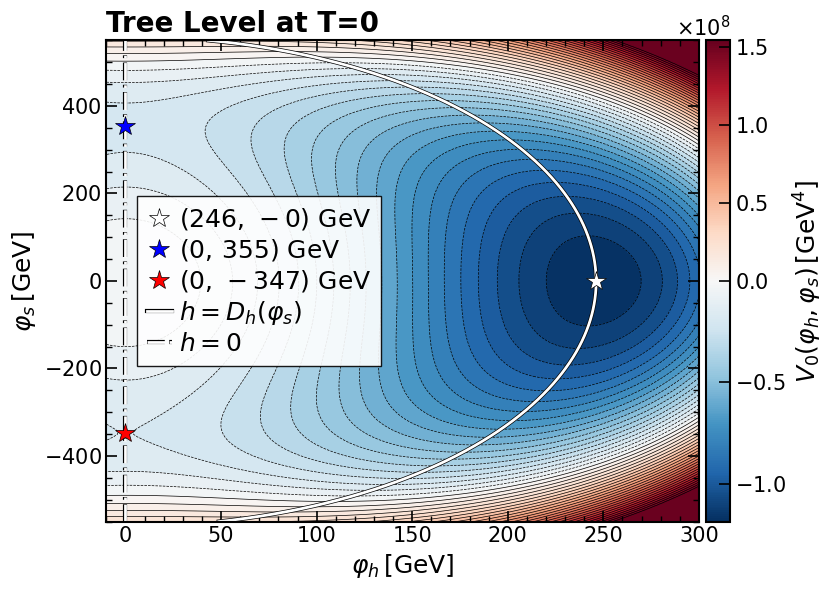

In [41]:
# Set the values of h & s 
hmin, hmax = (-10, 300)
smin, smax = (-550, 550)

# Create the Paths 
s_path  = np.linspace(smin, smax, 1000)
h_zeros = np.zeros_like(s_path)
h_plus  = np.full_like(s_path, np.nan)
h_minus = np.full_like(s_path, np.nan)

radicand = -s_path**2 * lHS + 2*muH2 - 2*s_path*muHS
valid = radicand >= 0
h_plus[valid]  =  np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))
h_minus[valid] = -np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))

# Potential Grid 
h_vals = np.linspace(hmin, hmax, 200)
s_vals = np.linspace(smin, smax, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.V0(X_grid).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.V0(np.array([[0.0, 0.0]]))

# Normalize the cmap
norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

# Create the Figure
fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(root_hp[-1], validX[-1], 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({root_hp[-1]:.0f},\,{validX[-1]:.0f})$ GeV')
ax.plot(0, minima_roots[0], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{minima_roots[0]:.0f})$ GeV')
ax.plot(0, minima_roots[1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{minima_roots[1]:.0f})$ GeV')
ax.plot(h_plus, s_path, label=r'$h=D_h(\varphi_s)$', color='w', lw=2, ls='-', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])
ax.plot(h_zeros, s_path, label=r'$h=0$', color='w', lw=2, ls='-.', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])

# Make it Pretty
ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "center left", bbox_to_anchor=(0.03, 0.5),ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/Z2_{m2}_{lHS:.4f}_{lS:.4f}_TL_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

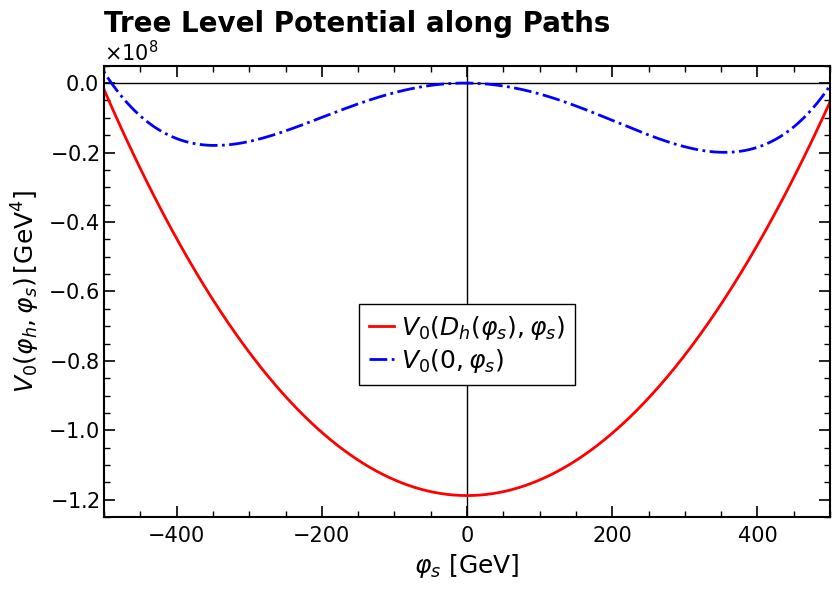

In [44]:
# Potential allong paths
sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)
SPath = np.linspace(sm,sp,500)
SPath0 = np.linspace(smin-500,smax+500,1000)

Vs0 = mu13*SPath0-0.5*muS2*SPath0**2-mu3/3*SPath0**3+lS/4*SPath0**4

Vs = (-(muH2**2)/(4*lH)
      + SPath*((muH2*muHS)/(2*lH) + mu13)
      - SPath**2*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - SPath**3*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - SPath**4*(3*lHS**2 - 12*lH*lS)/(48*lH))

# Create the plot
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(SPath, Vs, label=r'$V_{0}\left(D_h(\varphi_s),\varphi_s\right)$', color='r', lw=2, ls='-')
ax.plot(SPath0, Vs0, label=r'$V_{0}\left(0,\varphi_s\right)$', color='b', lw=2, ls='-.')

ax.set_xlim(-500, 500)
ax.set_ylim(-1.25e8, 0.5e7)

ax.set_xlabel(r'$\varphi_s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper center", bbox_to_anchor=(0.5, 0.5),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level Potential along Paths", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/Z2_{m2}_{lHS:.4f}_{lS:.4f}_TL_Path.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Coleman Weinberg ($T=0$)

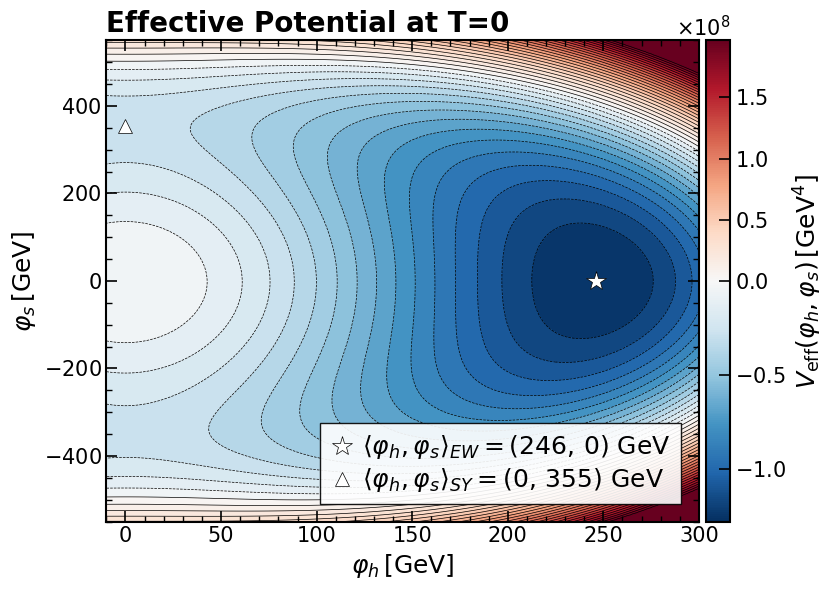

In [46]:
# Grid in (h, s)
h_vals = np.linspace(-10, 300, 200)
s_vals = np.linspace(-550, 550, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, 0.0).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), 0.0)

norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v, 0, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle_{{EW}} = ({v:.0f},\,{0:.0f})$ GeV')
ax.plot(0, w, 'w^', markersize=10, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle_{{SY}} = ({0:.0f},\,{w:.0f})$ GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Effective Potential at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/Z2_{m2}_{lHS:.4f}_{lS:.4f}_CW_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Phase Transition

In [42]:
trans = model.calcTcTrans()
Tc   = trans[0]['Tcrit']
high = trans[0]['high_vev']
low  = trans[0]['low_vev']
xi_c = abs(low[0] - high[0]) / Tc
print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xi_c:.2f}")

Tracing phase starting at x = [2.46220000e+02 3.93528453e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
....................................................................................................................................................................................................................................
Tracing phase starting at x = [-8.10005725e-06  3.33156476e+02] ; t = 132.219610063989
Tracing minimum down
traceMinimum t0 = 132.22
.....................................................
Tracing minimum up
traceMinimum t0 = 132.22
.........................................................
Tc = 129.8523 GeV  |  xi_c = 1.32


In [47]:
# Compute the rest

trans = model.findAllTransitions()
print()
print("The Model has",len(model.TnTrans),"transition(s)")

if len(model.TnTrans) != 0:
    Trans = model.TnTrans[0]

    Tc    = Trans['crit_trans']['Tcrit']
    highc = Trans['crit_trans']['high_vev']
    lowc  = Trans['crit_trans']['low_vev']
    xic   = abs(lowc[0] - highc[0]) / Tc
    Tn    = Trans['Tnuc']
    highn = Trans['high_vev']
    lown  = Trans['low_vev']
    xin   = abs(lown[0] - highn[0]) / Tc

    print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xi_c:.2f}")

Tunneling from phase 1 to phase 0 at T=125.9664
high_vev = [8.20782640e-05 3.34469978e+02]
low_vev = [179.80999636   5.70529016]
Path deformation converged. 47 steps. fRatio = 1.72109e-02
Path deformation converged. 15 steps. fRatio = 9.46660e-03
Path deformation converged. 8 steps. fRatio = 3.64650e-03
Path deformation converged. 1 steps. fRatio = 9.02810e-04
Tunneling from phase 1 to phase 0 at T=125.9669
high_vev = [1.28319598e-04 3.34469888e+02]
low_vev = [179.8090143    5.70578679]
Path deformation converged. 47 steps. fRatio = 1.72072e-02
Path deformation converged. 15 steps. fRatio = 9.45158e-03
Path deformation converged. 8 steps. fRatio = 3.74504e-03
Path deformation converged. 1 steps. fRatio = 8.60791e-04
Tunneling from phase 1 to phase 0 at T=128.968
high_vev = [1.23653795e-04 3.33872436e+02]
low_vev = [173.61792994  10.5763428 ]
Path deformation converged. 47 steps. fRatio = 1.97084e-02
Path deformation converged. 19 steps. fRatio = 1.61007e-02
Path deformation converged. 

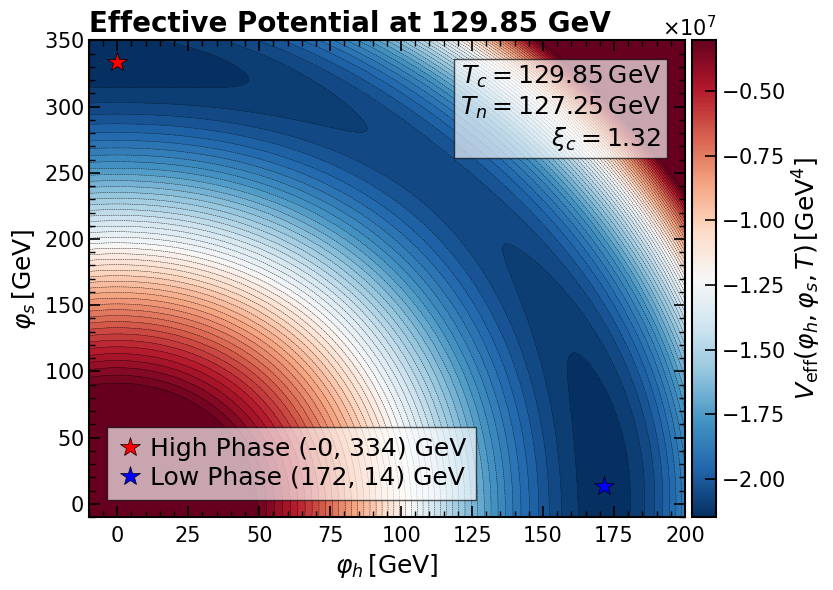

In [51]:
# Grid in (h, s)
h_vals = np.linspace(-10, 200, 200)
s_vals = np.linspace(-10, 350, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, Tc).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 90))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), Tc)

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=55, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=55, colors='k', linewidths=0.3, alpha=1)

ax.plot(high[0], high[1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'High Phase ({-high[0]:.0f}, {high[1]:.0f}) GeV')
ax.plot(low[0], low[1], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'Low Phase ({low[0]:.0f}, {low[1]:.0f}) GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s,T) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower left", bbox_to_anchor=(0.01, 0.01), 
          ncol = 1, edgecolor="black", framealpha=0.65, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

annotation = (rf"$T_c   = {Tc:.2f} \, \mathrm{{GeV}}$"
              "\n"rf"$T_n = {Tn:.2f}\, \mathrm{{GeV}}$"
              "\n"rf"$\xi_c = {xi_c:.2f}$")
ax.text(0.96, 0.95, annotation,transform=ax.transAxes,fontsize=18,verticalalignment='top',horizontalalignment='right',
       bbox=dict(facecolor='white', edgecolor='black', alpha=0.65))

plt.title(rf"Effective Potential at {Tc:.2f} GeV", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/Z2_{m2}_{lHS:.4f}_{lS:.4f}_Tc_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Manual Phase Transition

In [54]:
import numpy as np
import signal
from cosmoTransitions import pathDeformation as ctpath

# Assumes `physical_to_lagrangian` and `xSM` are already defined/imported
# from your existing model module, as in your earlier scan script.


class TimeoutException(Exception):
    pass


def _timeout_handler(signum, frame):
    raise TimeoutException


def compute_action(model, phase_high, phase_low, T, max_seconds=60,
                    bend_axis=1, bend_factor=1.15, tol=1e-4, maxiter=500):
    """Manual bounce action S3(T) between two phases, warm-started path + timeout."""

    V = lambda x: model.Vtot(np.array([x]), T)[0]
    dV = lambda x: model.gradV(np.array([x]), T)[0]

    n_points = 30
    straight = np.linspace(phase_high, phase_low, n_points)
    V_along = np.array([V(pt) for pt in straight])
    i_max = np.argmax(V_along)

    bent_point = straight[i_max].copy()
    bent_point[bend_axis] *= bend_factor
    path_guess = straight.copy()
    path_guess[i_max] = bent_point

    signal.signal(signal.SIGALRM, _timeout_handler)
    signal.alarm(max_seconds)
    try:
        result = ctpath.fullTunneling(
            path_pts=path_guess, V=V, dV=dV,
            tol=tol, maxiter=maxiter, fixEndCutoff=1e-3,
        )
        S3, status = result.action, "ok"
    except TimeoutException:
        S3, status = np.nan, "timeout"
    except Exception as e:
        S3, status = np.nan, f"failed: {type(e).__name__}: {e}"
    finally:
        signal.alarm(0)

    return S3, status


def find_Tn(model, phase_high, phase_low, Tc, T_low=1.0, n_steps=40, max_seconds=60):
    """Downward T-scan from Tc to find where S3/T crosses 140."""
    T_grid = np.linspace(Tc * 0.999, T_low, n_steps)
    records = []

    for T in T_grid:
        S3, status = compute_action(model, phase_high, phase_low, T, max_seconds)
        if status != "ok":
            records.append((T, np.nan, status))
            continue
        records.append((T, S3 / T, status))
        if S3 / T <= 140:
            break

    good = np.array([(T, val) for T, val, s in records if s == "ok"])
    if len(good) < 2 or np.min(good[:, 1]) > 140:
        return np.nan, records

    Ts, ratios = good[:, 0], good[:, 1]
    Tn = np.interp(140, ratios[::-1], Ts[::-1])
    return Tn, records

In [55]:
m1  = 125.20
m2  = 30
th  = 0.001
v0  = 246.22
lHS = 0.05
lS  = 0.005
mu3 = 1e-4 * v0

params = (m1, m2, th, v0, lHS, lS, mu3)
result = scan_point_nucleation(params)

for k, v in result.items():
    if k != 'action_records':
        print(f"{k}: {v}")

if result['action_records'] is not None:
    print("\nS3/T trace:")
    for T, ratio, status in result['action_records']:
        print(f"  T={T:.3f}  S3/T={ratio}  status={status}")

Tracing phase starting at x = [2.46220000e+02 3.93528453e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
....................................................................................................................................................................................................................................
Tracing phase starting at x = [-8.10005725e-06  3.33156476e+02] ; t = 132.219610063989
Tracing minimum down
traceMinimum t0 = 132.22
.....................................................
Tracing minimum up
traceMinimum t0 = 132.22
.........................................................
m1: 125.2
m2: 30
th: 0.001
v0: 246.22
lHS: 0.05
lS: 0.005
mu3: 0.024622
Tc: 129.85233019107315
xic: 1.3218293181355933
Tn: nan
status: Trapped_FOPT
error_msg: 

S3/T trace:
  T=129.722  S3/T=nan  status=failed: TypeError: fullTunneling() got an unexpected keyword argument 'tol'
  T=126.422  S3/T=nan  status=failed: TypeError: fullTunneling() got an unexpected keyword a

## Analytical Scan

In [2]:
# Fixed Inputs
m1, v   = 125.2, 246.22
th, mu3 = 0.0, 0.0
g  = 0.6528226789050443
gp = 0.34994875330215097
yb = 0.024025892825142788
yt = 0.9902137038141565

# Create the grid
lHS = np.geomspace(1e-3, 1, 100)
lS  = np.geomspace(1e-6,  1,  100)
m2  = np.linspace(10,  60,  100)
LHS, LS, M2 = np.meshgrid(lHS, lS, m2, indexing='ij')

# Lagrangian Parameters
p = physical_to_lagrangian(m1=m1, m2=M2, theta=th, v=v, lHS=LHS, lS=LS, mu3=mu3)
lH, muH2, muS2 = p['lH'], p['muH2'], p['muS2']

# Thermal Coefficients
cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*LHS) / 48
cS = LS/4 + LHS/6

# Transition Temperatures
T0h2 = muH2 / cH
T0s2 = muS2 / cS
Tc2 = (-np.sqrt(LS)*muH2 + np.sqrt(lH)*muS2) / (cS*np.sqrt(lH) - cH*np.sqrt(LS))

# VEVs
vTc2 = (muH2 - cH*Tc2) / lH
wTc2 = (muS2 - cS*Tc2) / LS

# Validity Mask
valid = (
    (muS2 > 0) & (LS > 0) & (Tc2 > 0) 
    & (Tc2 < T0h2) & (Tc2 < T0s2) & (T0s2 > T0h2) 
    & (LHS > 2*np.sqrt(lH*LS)) & (LS > (LHS*v**2 - 2*M2**2)**2 / (2*v**2*m1**2))
)

# Save only relevant data
idx = np.where(valid)
results = dict(
    lHS=LHS[idx], lS=LS[idx], m2=M2[idx],
    Tc=np.sqrt(Tc2[idx]),
    vTc=np.sqrt(vTc2[idx]),
    wTc=np.sqrt(wTc2[idx]),
    xic=np.sqrt(vTc2[idx])/np.sqrt(Tc2[idx])
)

results_df = pd.DataFrame(results)

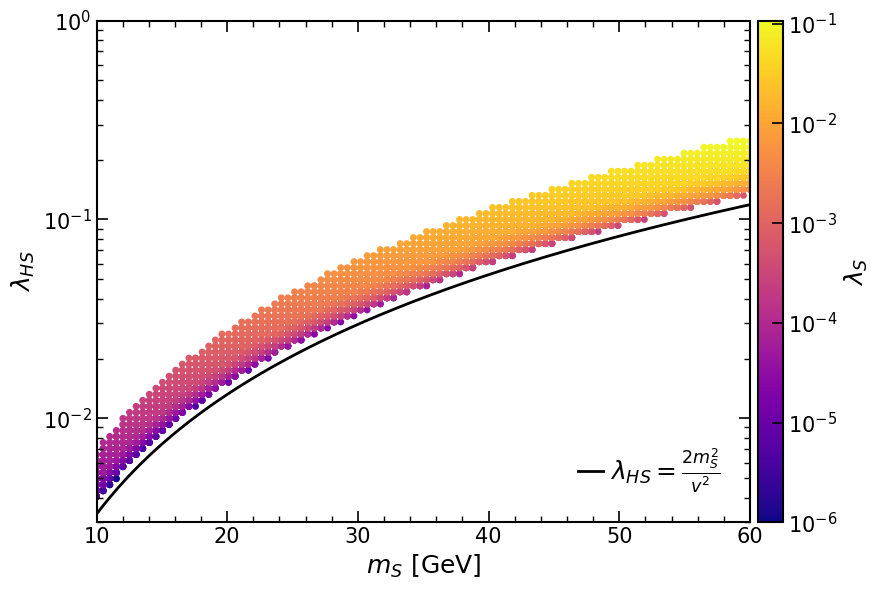

In [10]:
df = results_df[(results_df.xic>1)&(results_df.Tc>100)]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_S^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(10, 60)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"$\mathbb{Z}_2$ limit. $\exists T_n$", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Analytic_m2-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()


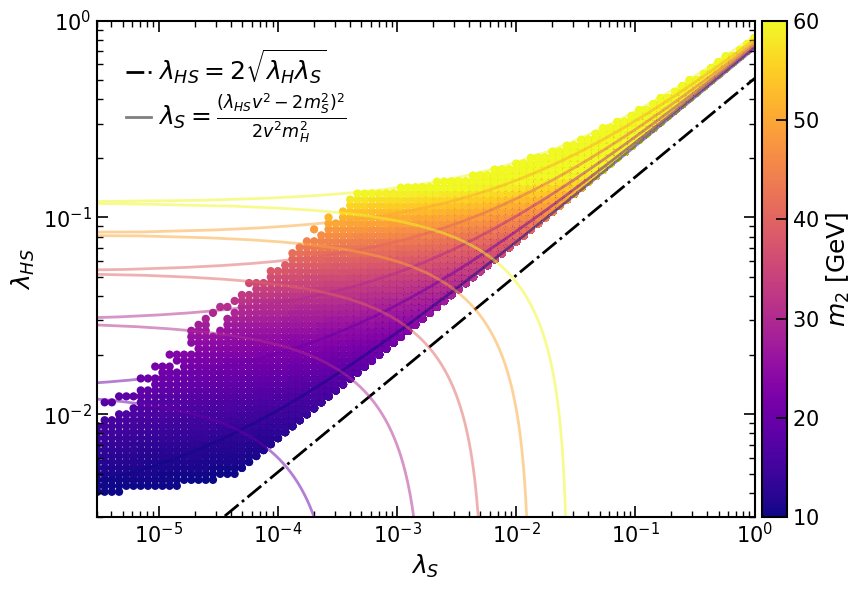

In [97]:
df = results_df[(results_df.xic>1)]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['m2'].min(), vmax=df['m2'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(2*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

m2_lines = [10, 20, 30, 40, 50, 60]

for m2_i in m2_lines:
    lS_curve = lS_min(lHS_vals, m2_i)
    ax.plot(lS_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2)

sc = ax.scatter(df['lS'], df['lHS'], c=df['m2'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(3e-6, 1e0)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$m_2\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$"),
                mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{(\lambda_{HS}v^2 - 2m_S^2)^2}{2v^2m_H^2}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"$\mathbb{Z}_2$ Limit. $\exists T_n$", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Analytic_lS-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [95]:
results_df[(results_df.xic>1)&(results_df.m2>19.5)&(results_df.m2<20.5)&(results_df.lHS>1e-1)]

,lHS,lS,m2,Tc,vTc,wTc,xic
14813,0.107227,0.017475,19.59596,11.029061,245.450803,404.800834,22.254914
14814,0.107227,0.017475,20.10101,16.773286,244.437239,403.129251,14.573008
14893,0.107227,0.020092,19.59596,40.604767,235.580488,375.201653,5.801794
14894,0.107227,0.020092,20.10101,42.386786,234.602543,373.644111,5.534804
15499,0.114976,0.020092,20.10101,8.032855,245.811934,391.496957,30.600817
15580,0.114976,0.023101,19.59596,38.214890,236.812538,364.232424,6.196866
15581,0.114976,0.023101,20.10101,39.981785,235.903080,362.833620,5.900264
16291,0.123285,0.026561,19.59596,35.838870,237.958472,353.446404,6.639676
16292,0.123285,0.026561,20.10101,37.596797,237.112206,352.189421,6.306713
17029,0.132194,0.030539,19.59596,33.466832,239.025087,342.858062,7.142149


## Results of Scan

In [3]:
Df = pd.read_csv('Z2_Scan_Tn.csv')

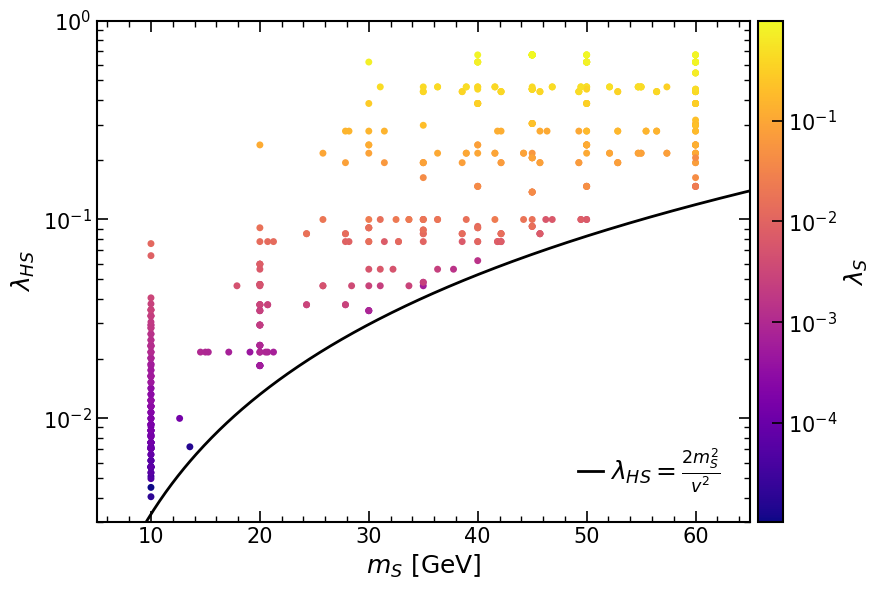

In [10]:
df = Df[(Df.status=='Nucleation_FOPT')&(Df.xic>1)]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_S^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(5, 65)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"$\mathbb{Z}_2$ limit. $\exists T_n$", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Scan_m2-lHS_nucleation.pdf", format="pdf", bbox_inches="tight")
plt.show()


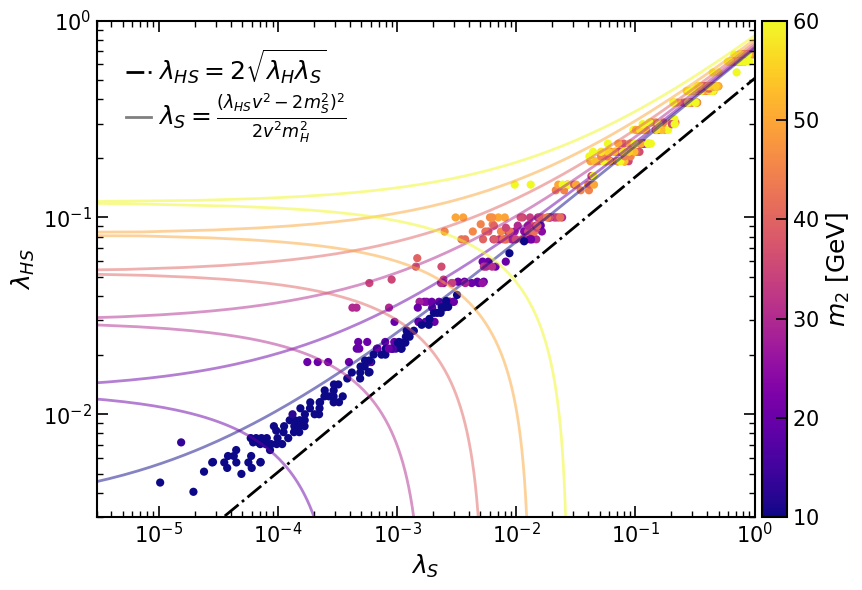

In [9]:
df = Df[(Df.status=='Nucleation_FOPT')&(Df.xic>1)]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['m2'].min(), vmax=df['m2'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(2*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

m2_lines = [10, 20, 30, 40, 50, 60]

for m2_i in m2_lines:
    lS_curve = lS_min(lHS_vals, m2_i)
    ax.plot(lS_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2)

sc = ax.scatter(df['lS'], df['lHS'], c=df['m2'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(3e-6, 1e0)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$m_2\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$"),
                mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{(\lambda_{HS}v^2 - 2m_S^2)^2}{2v^2m_H^2}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"$\mathbb{Z}_2$ Limit. $\exists T_n$", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Scan_lS-lHS_Nucleation.pdf", format="pdf", bbox_inches="tight")
plt.show()
